In [13]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
df = pd.read_csv("gcc_ecommerce_sales.csv")
print(df)

    Order_ID Product Category  Quantity  Price  Revenue Order_Date
0          1    Rice     Food         5  25000      NaN     01-Apr
1          2   Bread     Food         8    800   6400.0     02-Apr
2          3    Milk    Dairy        11   1500  16500.0     03-Apr
3          4    Eggs    Dairy        14    100      NaN     04-Apr
4          5   Sugar     Food        17   1200  20400.0     05-Apr
..       ...     ...      ...       ...    ...      ...        ...
95        96   Beans     Food        10   1800  18000.0     06-Apr
96        97  Butter    Dairy        13   2500      NaN     07-Apr
97        98  Cheese    Dairy        16   3500  56000.0     08-Apr
98        99   Pasta     Food        19   1500  28500.0     09-Apr
99       100  Yogurt    Dairy        22   1000      NaN     10-Apr

[100 rows x 7 columns]


In [15]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Order_ID Product Category  Quantity  Price  Revenue Order_Date
0         1    Rice     Food         5  25000      NaN     01-Apr
1         2   Bread     Food         8    800   6400.0     02-Apr
2         3    Milk    Dairy        11   1500  16500.0     03-Apr
3         4    Eggs    Dairy        14    100      NaN     04-Apr
4         5   Sugar     Food        17   1200  20400.0     05-Apr


In [16]:
print("\nDataset Information:")
print(df.info())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    100 non-null    int64  
 1   Product     100 non-null    object 
 2   Category    100 non-null    object 
 3   Quantity    100 non-null    int64  
 4   Price       100 non-null    int64  
 5   Revenue     66 non-null     float64
 6   Order_Date  100 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.6+ KB
None


In [17]:
# DATA CLEANING
# Check missing values
print("\nMissing Values:")



Missing Values:


In [18]:
print(df.isnull().sum())



Order_ID       0
Product        0
Category       0
Quantity       0
Price          0
Revenue       34
Order_Date     0
dtype: int64


In [19]:
 # Calculate missing Revenue values
df["Revenue"] = df["Revenue"].fillna(
    df["Quantity"] * df["Price"])
print(df)


    Order_ID Product Category  Quantity  Price   Revenue Order_Date
0          1    Rice     Food         5  25000  125000.0     01-Apr
1          2   Bread     Food         8    800    6400.0     02-Apr
2          3    Milk    Dairy        11   1500   16500.0     03-Apr
3          4    Eggs    Dairy        14    100    1400.0     04-Apr
4          5   Sugar     Food        17   1200   20400.0     05-Apr
..       ...     ...      ...       ...    ...       ...        ...
95        96   Beans     Food        10   1800   18000.0     06-Apr
96        97  Butter    Dairy        13   2500   32500.0     07-Apr
97        98  Cheese    Dairy        16   3500   56000.0     08-Apr
98        99   Pasta     Food        19   1500   28500.0     09-Apr
99       100  Yogurt    Dairy        22   1000   22000.0     10-Apr

[100 rows x 7 columns]


In [20]:
# Convert Order_Date to datetime format
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%b",
    errors="coerce"
)


In [21]:
print("\nCleaned Data:")
print(df.head())



Cleaned Data:
   Order_ID Product Category  Quantity  Price   Revenue Order_Date
0         1    Rice     Food         5  25000  125000.0 1900-04-01
1         2   Bread     Food         8    800    6400.0 1900-04-02
2         3    Milk    Dairy        11   1500   16500.0 1900-04-03
3         4    Eggs    Dairy        14    100    1400.0 1900-04-04
4         5   Sugar     Food        17   1200   20400.0 1900-04-05


In [22]:
# Create Month column
df["Month"] = df["Order_Date"].dt.month_name()

print(df)
print(df.dtypes)

    Order_ID Product Category  Quantity  Price   Revenue Order_Date  Month
0          1    Rice     Food         5  25000  125000.0 1900-04-01  April
1          2   Bread     Food         8    800    6400.0 1900-04-02  April
2          3    Milk    Dairy        11   1500   16500.0 1900-04-03  April
3          4    Eggs    Dairy        14    100    1400.0 1900-04-04  April
4          5   Sugar     Food        17   1200   20400.0 1900-04-05  April
..       ...     ...      ...       ...    ...       ...        ...    ...
95        96   Beans     Food        10   1800   18000.0 1900-04-06  April
96        97  Butter    Dairy        13   2500   32500.0 1900-04-07  April
97        98  Cheese    Dairy        16   3500   56000.0 1900-04-08  April
98        99   Pasta     Food        19   1500   28500.0 1900-04-09  April
99       100  Yogurt    Dairy        22   1000   22000.0 1900-04-10  April

[100 rows x 8 columns]
Order_ID               int64
Product               object
Category          

In [23]:
# Total Revenue
total_revenue = df["Revenue"].sum()
print("\nTotal Revenue:", total_revenue)


Total Revenue: 11351200.0


In [24]:
# Average Revenue
average_revenue = df["Revenue"].mean()
print("Average Revenue:", average_revenue)



Average Revenue: 113512.0


In [25]:
# Revenue by Product
revenue_by_product = df.groupby("Product")["Revenue"].sum()
print("\nRevenue by Product:")
print(revenue_by_product)




Revenue by Product:
Product
Beans      572400.0
Bread      248000.0
Butter     730000.0
Cheese    1127000.0
Eggs        37000.0
Milk       510000.0
Pasta      444000.0
Rice      7000000.0
Sugar      412800.0
Yogurt     270000.0
Name: Revenue, dtype: float64


In [26]:
# Top Performing Product
top_product = revenue_by_product.idxmax()
top_revenue = revenue_by_product.max()
print("\nTop Performing Product:")
print(top_product, "-", top_revenue)



Top Performing Product:
Rice - 7000000.0


In [27]:
# Revenue by Category
category_revenue = df.groupby("Category")["Revenue"].sum()
print("\nRevenue by Category:")
print(category_revenue)



Revenue by Category:
Category
Dairy    2674000.0
Food     8677200.0
Name: Revenue, dtype: float64


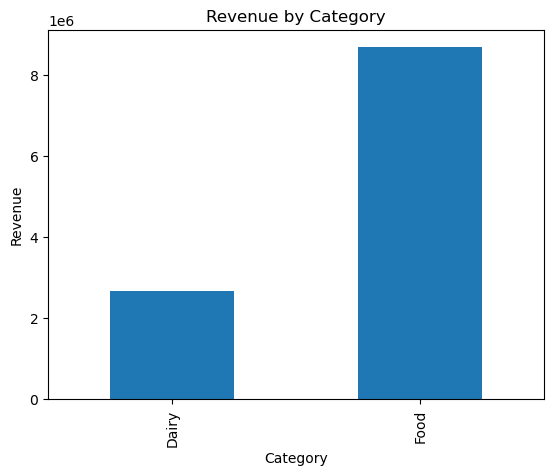

In [29]:
# Bar chart -revenue by category
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

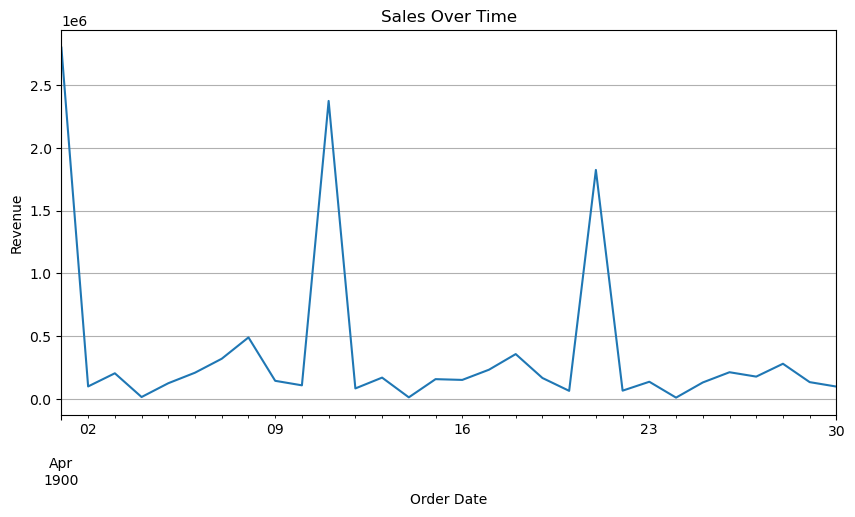

In [26]:
# Line Chart - Sales Over Time
daily_sales = df.groupby("Order_Date")["Revenue"].sum()
plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()



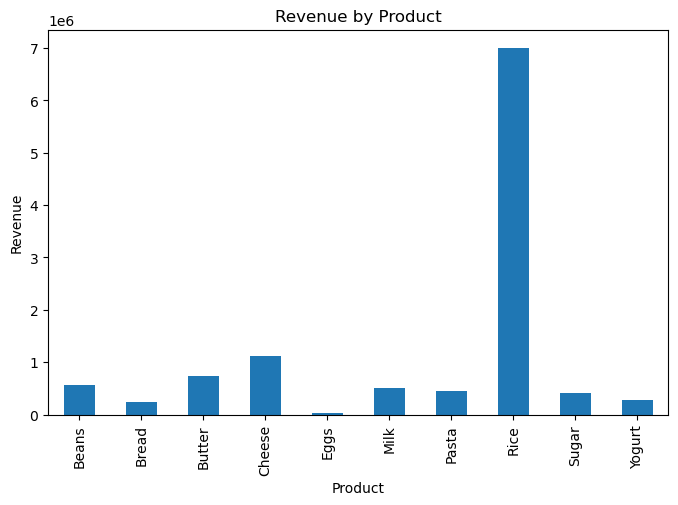

In [27]:
# Bar Chart - Revenue by Product
plt.figure(figsize=(8,5))
revenue_by_product.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()


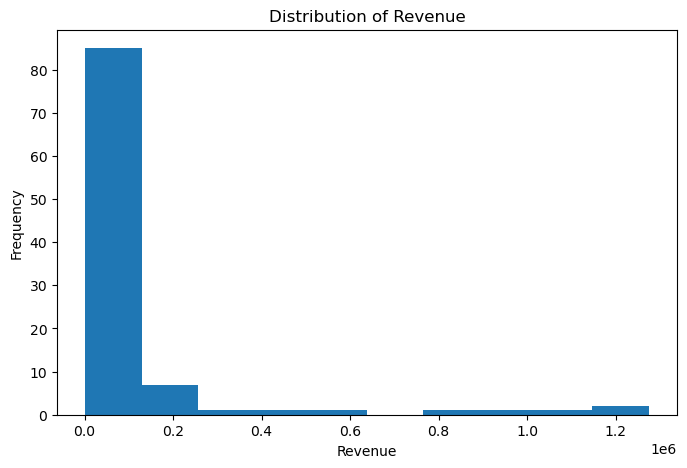

In [28]:
# Histogram - Revenue Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=10)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Insights and Recommendations

## Key Insights

1. Rice generated the highest revenue among all products, making it the top-performing product.

2. Food products contributed more revenue than Dairy products.

3. Revenue distribution shows that a few products account for a large portion of total sales.

4. Missing revenue values were successfully calculated using Quantity × Price, ensuring complete analysis.

## Business Recommendations

1. Increase inventory levels for Rice and other top-performing products to avoid stock shortages.

2. Introduce promotional campaigns for lower-performing products to improve sales.

3. Monitor sales trends regularly to identify peak demand periods and optimize stock planning.

4. Create product bundles and discounts to increase average order value.